In [5]:
import yfinance as yf 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings 
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, SimpleRNN
from sklearn.model_selection import KFold
from scikeras.wrappers import KerasClassifier, KerasRegressor
from sklearn.model_selection import RandomizedSearchCV
from keras.models import Sequential
from keras.callbacks import EarlyStopping
import tensorflow as tf

warnings.filterwarnings('ignore')

In [6]:
goog = yf.Ticker('GOOGL')
goog_6y = goog.history(period='6y')

# Data that I want to focus on are 'Open','High','Low','Closing', and Volume
goog = goog_6y.iloc[:,0:5]

# Diagnose whether there are null data 
goog.isnull().sum()


Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [8]:
# This time, let's divide data into train and test. The train ratio is 0.7
train_ratio = 0.7
train_len = int(train_ratio * goog.shape[0])
train_stock = goog[:train_len]
test_stock = goog[train_len:]

In [9]:
# Do scaling train data by using MinMaxScaler 
train = train_stock.copy()
scalers = {}
for i in train_stock.columns:
    scaler = MinMaxScaler(feature_range=(-1,1))
    s_s = scaler.fit_transform(train[i].values.reshape(-1,1))
    scalers['scaler_'+i]=scaler
    train[i] = s_s

In [10]:
# Likewise, do scaling test data too
test = test_stock.copy()
for i in train_stock.columns:
    scaler = scalers['scaler_'+i]
    s_s = scaler.transform(test[i].values.reshape(-1,1))
    test[i] = s_s

In [11]:
# Next, the below function is for making time series data. 
def split_series(series, n_past,n_future,target_col=list(range(len(goog.columns)))):
    X, y = list(), list()
    for window_start in range(len(series)):
        past_end = window_start + n_past
        future_end = past_end + n_future
        if future_end > len(series):
            break
        past, future = series[window_start:past_end,:], series[past_end:future_end,target_col]
        X.append(past)
        y.append(future)
    return np.array(X), np.array(y)

In [12]:
n_features = train.shape[1]  # 5 
n_past = 22
n_future = 1

X_train, y_train = split_series(train.values,n_past,n_future, target_col=goog.columns.get_loc('Close'))

test_rnn = pd.concat([train[-n_past:],test])


X_test, y_test = split_series(test_rnn.values, n_past,n_future, target_col=goog.columns.get_loc('Close') )

In [13]:
def build_rnn(n_neurons):
    model = Sequential()
    model.add(SimpleRNN(units=n_neurons, activation='tanh', input_shape=(n_past, n_features)))
    model.add(Dense(1, activation='tanh'))
    model.compile(loss='mse',optimizer=tf.keras.optimizers.RMSprop(0.001), metrics=['mse'])
    return model

In [16]:
kfold = KFold(n_splits = 3)

n_neurons = [10, 20, 30]
param_grid = dict(n_neurons=n_neurons)

model_candi = KerasRegressor(build_fn = build_rnn, n_neurons=n_neurons, verbose=0)
grid_rnn = RandomizedSearchCV(estimator=model_candi, cv=kfold, param_distributions=param_grid)

grid_rnn.fit(X_train, y_train, epochs=50, batch_size=20, verbose=0)

best_rnn = grid_rnn.best_estimator_

es = EarlyStopping(monitor='val_loss', mode='min', patience=5)
history_rnn = best_rnn.fit(X_train, y_train, epochs=50, batch_size=20, validation_split=0.2, callbacks=[es],
                            verbose=0)

train_mse = history_rnn.history['mse']
valid_mse = history_rnn.history['val_mse']

plt.plot(train_mse, label='train mse')
plt.plot(valid_mse, label='validation mse')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(loc='upper center', bbox_to_anchor=(0.5,-0.15), fancybox=True, shadow=False, ncol=2)

AttributeError: 'KerasRegressor' object has no attribute 'history'

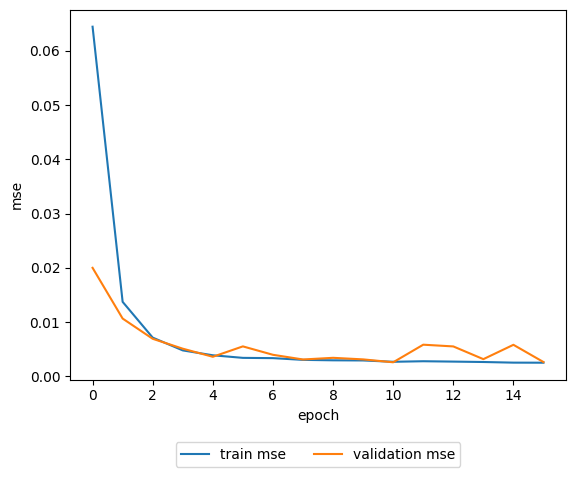

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, SimpleRNN
from keras.models import Sequential
from keras.callbacks import EarlyStopping
import tensorflow as tf

warnings.filterwarnings('ignore')

goog = yf.Ticker('GOOGL')
goog_6y = goog.history(period='6y')

# Data that I want to focus on are 'Open','High','Low','Closing', and 'Volume'
goog = goog_6y.iloc[:, 0:5]

# Diagnose whether there are null data
goog.isnull().sum()

# This time, let's divide data into train and test. The train ratio is 0.7
train_ratio = 0.7
train_len = int(train_ratio * goog.shape[0])
train_stock = goog[:train_len]
test_stock = goog[train_len:]

# Do scaling train data by using MinMaxScaler
train = train_stock.copy()
scalers = {}
for i in train_stock.columns:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    s_s = scaler.fit_transform(train[i].values.reshape(-1, 1))
    scalers['scaler_' + i] = scaler
    train[i] = s_s

# Likewise, do scaling test data too
test = test_stock.copy()
for i in train_stock.columns:
    scaler = scalers['scaler_' + i]
    s_s = scaler.transform(test[i].values.reshape(-1, 1))
    test[i] = s_s

# Next, the below function is for making time series data.
def split_series(series, n_past, n_future, target_col=list(range(len(goog.columns)))):
    X, y = list(), list()
    for window_start in range(len(series)):
        past_end = window_start + n_past
        future_end = past_end + n_future
        if future_end > len(series):
            break
        past, future = series[window_start:past_end, :], series[past_end:future_end, target_col]
        X.append(past)
        y.append(future)
    return np.array(X), np.array(y)

n_features = train.shape[1]  # 5
n_past = 22
n_future = 1

X_train, y_train = split_series(train.values, n_past, n_future, target_col=goog.columns.get_loc('Close'))

test_rnn = pd.concat([train[-n_past:], test])

X_test, y_test = split_series(test_rnn.values, n_past, n_future, target_col=goog.columns.get_loc('Close'))

def build_rnn(n_neurons):
    model = Sequential()
    model.add(SimpleRNN(units=n_neurons, activation='tanh', input_shape=(n_past, n_features)))
    model.add(Dense(1, activation='tanh'))
    model.compile(loss='mse', optimizer=tf.keras.optimizers.RMSprop(0.001), metrics=['mse'])
    return model

# KerasRegressor와 RandomizedSearchCV 제거
# 최적의 n_neurons 값은 임의로 20으로 설정
best_rnn = build_rnn(20)

es = EarlyStopping(monitor='val_loss', mode='min', patience=5)
history_rnn = best_rnn.fit(X_train, y_train, epochs=50, batch_size=20, validation_split=0.2, callbacks=[es],
                           verbose=0)

train_mse = history_rnn.history['mse']
valid_mse = history_rnn.history['val_mse']

plt.plot(train_mse, label='train mse')
plt.plot(valid_mse, label='validation mse')
plt.ylabel('mse')
plt.xlabel('epoch')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=False, ncol=2)
plt.show() # 그래프를 화면에 표시

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


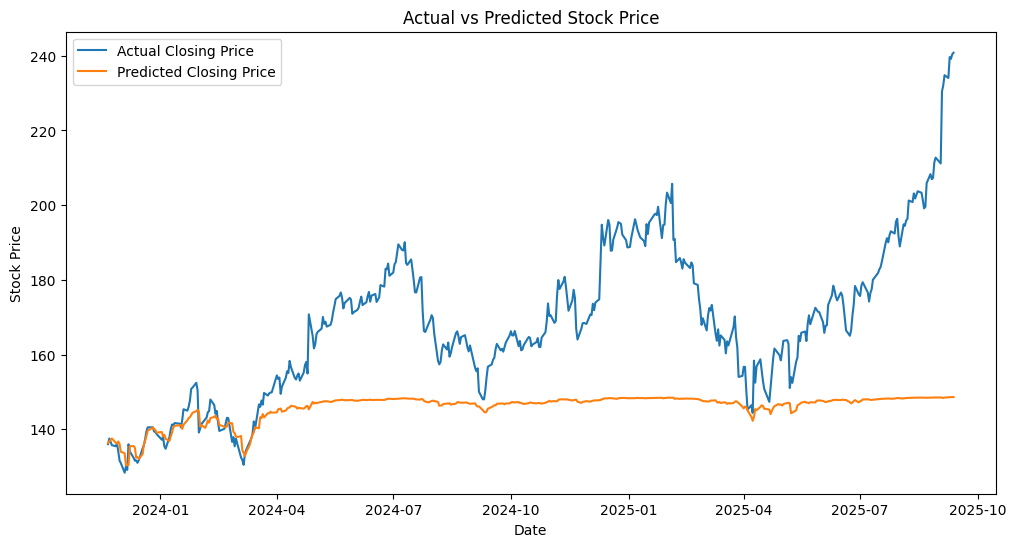

In [18]:
predictions = best_rnn.predict(X_test)

# y_test의 스케일링도 원래대로 복원
y_test_original = scalers['scaler_Close'].inverse_transform(y_test)

# predictions 스케일링 복원
predictions_original = scalers['scaler_Close'].inverse_transform(predictions)

# 결과를 DataFrame으로 만들어 인덱스를 맞춥니다.
plot_df = pd.DataFrame(index=test_stock.index)
plot_df['Actual'] = y_test_original.flatten()
plot_df['Predicted'] = predictions_original.flatten()

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(plot_df['Actual'], label='Actual Closing Price')
plt.plot(plot_df['Predicted'], label='Predicted Closing Price')
plt.title('Actual vs Predicted Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()